In [3]:
# For testing the little Shor circuit

import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching
import CircuitPresets as cp
import CircuitBuilder
import statevector as sv

In [4]:
state = sv.Statevector('00', True)
state.apply_gates('ZI')
print(state.ket())

1/√2.0 (|00⟩ - |11⟩)


In [5]:
cb = CircuitBuilder.CircuitBuilder(0, 0, 0, 0, 0, 0)
cb.ale('R 0 1 2 3')
cb.ale('H 0')
cb.ale('CX 0 1')
cb.ale('CX 0 2')
cb.ale('CX 0 3')
cb.ale('H 0')
cb.ale('MR(0.001) 0 1 2 3')
cb.sample(1000)

[('0000', 257),
 ('0010', 1),
 ('0110', 1),
 ('0111', 255),
 ('1000', 253),
 ('1111', 233)]

In [6]:
cb.get_circuit()

stim.Circuit('''
    R 0 1 2 3
    X_ERROR(0) 0 1 2 3
    H 0
    DEPOLARIZE1(0) 0
    CX 0 1
    DEPOLARIZE2(0) 0 1
    CX 0 2
    DEPOLARIZE2(0) 0 2
    CX 0 3
    DEPOLARIZE2(0) 0 3
    H 0
    DEPOLARIZE1(0) 0
    MR(0.001) 0 1 2 3
    X_ERROR(0) 0 1 2 3
''')

In [10]:
def simple_dict(sample):
    outdict = {}
    for s in sample:
        key = s[0]
        synz = int(key[0])
        synx = (int(key[1]) + int(key[2]) + int(key[3]) + int(key[4])) % 2
        logical = (int(key[5]) + int(key[6])) % 2
        newkey = f'{synz}, {synx}, {logical}'
        if newkey not in outdict:
            outdict[newkey] = 0
        outdict[newkey] += s[1]
    return outdict

def print_by_line(dict):
    for key, value in dict.items():
        print(f'{key}: {value}')


In [192]:
def littleshor(noise, n, state_preparation = '00',measurement_mode = 'Z1Z2'):
    #cb = CircuitBuilder.CircuitBuilder(0, 0, 0, 0, 0, noise)
    cb = CircuitBuilder.CircuitBuilder(noise, noise, noise, noise, noise, noise)

    # State preparation
    cb.ale('R 0 1 2 3')
    cb.ale('H 0')
    cb.ale('CX 0 1')
    cb.ale('CX 0 2')
    cb.ale('CX 0 3')
    # Prepare ancillae
    cb.ale('R 4 5 6 7 8')

    # Initial stabilizer checks
    # Z
    cb.idle_noise([0, 1, 2, 3])
    cb.ale('CX 0 4')
    cb.ale('CX 1 4')
    cb.ale('CX 2 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')
    # X
    cb.ale('H 5')
    cb.ale('CX 5 6')
    cb.ale('CX 5 7')
    cb.ale('CX 5 8')
    cb.ale('CX 5 0 6 1 7 2 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    
    # Noise rounds
    cb.begin_loop(n - 1)
    cb.idle_noise([0, 1, 2, 3])
    # Z
    cb.ale('CX 0 4')
    cb.ale('CX 1 4')
    cb.ale('CX 2 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')
    # X
    cb.ale('H 5')
    cb.ale('CX 5 6')
    cb.ale('CX 5 7')
    cb.ale('CX 5 8')
    cb.ale('CX 5 0 6 1 7 2 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    cb.add_detector([-5, -10])
    cb.add_detector([-4, -3, -2, -1, -9, -8, -7, -6])
    cb.end_loop()

    # Final measurement
    if measurement_mode == 'Z1Z2':
        cb.ale(f'MR({noise}) 0 1')
    elif measurement_mode == 'Z1Z3':
        cb.ale(f'MR({noise}) 0 2')
    cb.add_detector([-2,-1])    
    return cb.get_circuit()

# Measurement format: abbbbcc 
# a = Z check
# b = X check
# c = logical readout Z1Z2

In [282]:
cb = CircuitBuilder.CircuitBuilder(0.01, 0.01, 0.01, 0.01, 0.01, 0.01)
cb.al('H 0')
cb.al('CX 0 1')
cb.al('CX 0 2')
cb.al('CX 0 3')

cb.begin_loop(10)
cb.al('TICK')
cb.al('CX 0 4 1 4 2 4 3 4')
cb.al(f'MR({0}) 4')
cb.al('TICK')
cb.al('H 5')
cb.al('CX 5 6 5 7 5 8')
cb.al('CX 5 0 6 1 7 2 8 3')
cb.al('H 5 6 7 8')
cb.al(f'MR({0}) 5 6 7 8')
cb.end_loop()

cb.al('MR(0) 0 1')

print(','.join(list(str(cb.get_circuit().diagram()))))


 , , , , ,/,-,-,-,-,-,\, ,/,R,E,P, ,1,0, , , ,/,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,\, ,/,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,\, ,\,
,q,0,:, ,-,H,-,@,-,@,-,@,-,|,-,-,-,-,-,-,-,-,-,@,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,X,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,|,-,M,R,(,0,),:,r,e,c,[,5,0,],-,
, , , , , , , ,|, ,|, ,|, ,|, , , , , , , , , ,|, , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,|, , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,|,
,q,1,:, ,-,-,-,X,-,|,-,|,-,|,-,-,-,-,-,-,-,-,-,|,-,@,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,|,-,X,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,|,-,M,R,(,0,),:,r,e,c,[,5,1,],-,
, , , , , , , , , ,|, ,|, ,|, , , , , , , , , ,|, ,|, , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,|, ,|, , , , , , , , , , , , , , , , , , , , , , , , , , , ,|,
,q,2,:, ,-,-,-,-,-,X,-,|,-,|,-,

In [193]:
def littleshorgauge(noise, n, state_preparation = '00',measurement_mode = 'Z1Z2'):
    #cb = CircuitBuilder.CircuitBuilder(0, 0, 0, 0, 0, noise)
    cb = CircuitBuilder.CircuitBuilder(noise, noise, noise, noise, noise, noise)

    # State preparation
    cb.ale('R 0 1 2 3')
    cb.ale('H 0')
    cb.ale('CX 0 1')
    cb.ale('CX 0 2')
    cb.ale('CX 0 3')
    # Prepare ancillae
    cb.ale('R 4 5 6 7 8')

    # Initial stabilizer checks
    cb.idle_noise([0, 1, 2, 3])
    # X
    cb.ale('H 5')
    cb.ale('CX 5 6')
    cb.ale('CX 5 7')
    cb.ale('CX 5 8')
    cb.ale('CX 5 0 6 1 7 2 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    # gauge Z1Z3
    cb.ale('CX 0 4')
    cb.ale('CX 2 4')
    cb.ale(f'MR({noise}) 4')
    # gauge Z2Z4
    cb.ale('CX 1 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')

    # Noise rounds
    cb.begin_loop(n - 1)
    cb.idle_noise([0, 1, 2, 3])
    # X
    cb.ale('H 5')
    cb.ale('CX 5 6')
    cb.ale('CX 5 7')
    cb.ale('CX 5 8')
    cb.ale('CX 5 0 6 1 7 2 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    # gauge Z1Z3
    cb.ale('CX 0 4')
    cb.ale('CX 2 4')
    cb.ale(f'MR({noise}) 4')
    # gauge Z2Z4
    cb.ale('CX 1 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')

    cb.add_detector([-6, -5, -4, -3, -12, -11, -10, -9])
    cb.add_detector([-2, -1, -8, -7])
    cb.end_loop()

    # Final measurement
    if measurement_mode == 'Z1Z2':
        cb.ale(f'MR({noise}) 0 1')
    elif measurement_mode == 'Z1Z3':
        cb.ale(f'MR({noise}) 0 2')
    cb.add_detector([-2,-1])    
    return cb.get_circuit()

# Measurement format: abbbbcc 
# a = Z check
# b = X check
# c = logical readout Z1Z2

In [ ]:
def littleshorgaugex(noise, n, state_preparation = '00',measurement_mode = 'Z1Z2'):
    #cb = CircuitBuilder.CircuitBuilder(0, 0, 0, 0, 0, noise)
    cb = CircuitBuilder.CircuitBuilder(noise, noise, noise, noise, noise, noise)

    # State preparation
    cb.ale('R 0 1 2 3')
    cb.ale('H 0')
    cb.ale('CX 0 1')
    cb.ale('CX 0 2')
    cb.ale('CX 0 3')
    # Prepare ancillae
    cb.ale('R 4 5 6 7 8')

    # Initial stabilizer checks
    cb.idle_noise([0, 1, 2, 3])
    # Z
    cb.ale('CX 0 4')
    cb.ale('CX 1 4')
    cb.ale('CX 2 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')
    # gauge X1X3
    cb.ale('H 5')
    cb.ale('CX 5 7')
    cb.ale('CX 5 0 7 2')
    cb.ale('H 6')
    cb.ale('CX 6 8')
    cb.ale('CX 6 1 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')


    # Noise rounds
    cb.begin_loop(n - 1)
    cb.idle_noise([0, 1, 2, 3])
    # Z
    cb.ale('CX 0 4')
    cb.ale('CX 1 4')
    cb.ale('CX 2 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')
    # X
    cb.ale('H 5')
    cb.ale('CX 5 7')
    cb.ale('CX 5 0 7 2')
    cb.ale('H 6')
    cb.ale('CX 6 8')
    cb.ale('CX 6 1 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    cb.add_detector([-5, -10])
    cb.add_detector([-4, -3, -2, -1, -9, -8, -7, -6])
    
    cb.end_loop()

    # Final measurement
    if measurement_mode == 'Z1Z2':
        cb.ale(f'MR({noise}) 0 1')
    elif measurement_mode == 'Z1Z3':
        cb.ale(f'MR({noise}) 0 2')
    cb.add_detector([-2,-1])    
    return cb.get_circuit()

# Measurement format: abbbbcc 
# a = Z check
# b = X check
# c = logical readout Z1Z2

In [465]:
def littleshorx(noise, n, state_preparation = '00', measurement_mode = 'X1X2'):
    cb = CircuitBuilder.CircuitBuilder(noise, noise, noise, noise, noise, noise)

    # State preparation
    cb.ale('R 0 1 2 3')
    cb.ale('H 0')
    cb.ale('CX 0 1')
    cb.ale('CX 0 2')
    cb.ale('CX 0 3')
    cb.ale('H 0 1 2 3')
    # Prepare ancillae
    cb.ale('R 4 5 6 7 8')

    # Initial stabilizer checks
    # Z
    cb.idle_noise([0, 1, 2, 3])
    cb.ale('CX 0 4')
    cb.ale('CX 1 4')
    cb.ale('CX 2 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')
    # X
    cb.ale('H 5')
    cb.ale('CX 5 6')
    cb.ale('CX 5 7')
    cb.ale('CX 5 8')
    cb.ale('CX 5 0 6 1 7 2 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    
    # Noise rounds
    cb.begin_loop(n - 1)
    cb.idle_noise([0, 1, 2, 3])
    # Z
    cb.ale('CX 0 4')
    cb.ale('CX 1 4')
    cb.ale('CX 2 4')
    cb.ale('CX 3 4')
    cb.ale(f'MR({noise}) 4')
    # X
    cb.ale('H 5')
    cb.ale('CX 5 6')
    cb.ale('CX 5 7')
    cb.ale('CX 5 8')
    cb.ale('CX 5 0 6 1 7 2 8 3')
    cb.ale('H 5 6 7 8')
    cb.ale(f'MR({noise}) 5 6 7 8')
    cb.add_detector([-5, -10])
    cb.add_detector([-4, -3, -2, -1, -9, -8, -7, -6])
    cb.end_loop()

    # Final measurement
    if measurement_mode == 'X1X2':
        cb.ale('H 0 1')
        cb.ale(f'MR({noise}) 0 1')
    elif measurement_mode == 'X1X3':
        cb.ale('H 0 2')
        cb.ale(f'MR({noise}) 0 2')
    cb.add_detector([-2,-1])    
    return cb.get_circuit()




In [23]:
sample = cb.sample(100000)
sampledict = simple_dict(sample)
for i in range(1, 100):
    newsample = simple_dict(cb.sample(100000))
    for key, value in newsample.items():
        if key in sampledict:
            sampledict[key] += value
        else:
            sampledict[key] = value
print_by_line(sampledict)

IndexError: string index out of range

In [284]:
c = littleshor(0.001, 3, 'Z1Z2')
sample = c.compile_detector_sampler().sample(1000000)
samplefiltered = sample[sample[:,0] == 0]
samplefiltered = samplefiltered[samplefiltered[:,1] == 0]
samplefiltered = samplefiltered[samplefiltered[:,2] == 0]
samplefiltered = samplefiltered[samplefiltered[:,3] == 0]
print(len(samplefiltered), len(sample))
print(sum(samplefiltered[:,4]), sum(sample[:,4]))


933310 1000000
9075 22402


In [194]:
c = littleshorgauge(0.001, 3, 'Z1Z2')
sample = c.compile_detector_sampler().sample(100000)
print(sample)

[[False False False False False]
 [False False False False False]
 [False False False False False]
 ...
 [False False False False False]
 [False False False False False]
 [False False False False False]]


In [268]:
c = littleshorgauge(0.001, 3, 'Z1Z2')
sample = c.compile_detector_sampler().sample(100000)
samplefiltered = sample[sample[:,0] == 0]
samplefiltered = samplefiltered[samplefiltered[:,1] == 0]
samplefiltered = samplefiltered[samplefiltered[:,2] == 0]
samplefiltered = samplefiltered[samplefiltered[:,3] == 0]
print(len(samplefiltered), len(sample))
print(sum(samplefiltered[:,4]), sum(sample[:,4]))


92737 100000
927 2257


In [469]:
littleshorgaugex(0.001, 3, 'Z1Z2').diagram()


/REP 2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        \
q0: -R-X_ERROR(0.001)-H-DEPOLARIZE1(0.001)-@-DEPOLARIZE2(0.001)-@-DEPOLARIZE2(0.001)-@-DEPOLARIZE2(0.001)-DEPOLARIZE1(0.001)-@-DEPOLARIZE2(0.001)----------------------------------------------------------------------------------------------------------------------------------------X---DEPOLARIZE2(0.001)-------------------------------------------------------------------------------------------------------------------------------------------------------------|------DEPOLARIZE1(0.001)-@-DEPOLARIZE2(0.001)-----------------------------------------------------------------------------------------------------------------------------------------------X---DEPOLARIZE2(0.001)-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-MR(0.001):rec[15]-X_ERROR(0.001)-DETECTOR:D4=rec[15]*rec[16]-
                                           | |                  | |                  | |                                     | |                                                                                                                                                         |   |                                                                                                                                                                              |                         | |                                                                                                                                                                |   |                                                                                                                                                                                                                                                                                                                                                            |
q1: -R-X_ERROR(0.001)----------------------X-DEPOLARIZE2(0.001)-|-|------------------|-|------------------DEPOLARIZE1(0.001)-|-|------------------@-DEPOLARIZE2(0.001)-------------------------------------------------------------------------------------------------------------------|---|-------------------------------------------------------------------------------X---DEPOLARIZE2(0.001)-------------------------------------------------------------------------|------DEPOLARIZE1(0.001)-|-|------------------@-DEPOLARIZE2(0.001)--------------------------------------------------------------------------------------------------------------------------|---|-------------------------------------------------------------------------------X---DEPOLARIZE2(0.001)-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-MR(0.001):rec[16]-X_ERROR(0.001)-----------------------------
                                                                | |                  | |                                     | |                  | |                                                                                                                                    |   |                                  

In [466]:
c = littleshorgaugex(0.001, 3, 'Z1Z2')
sample = c.compile_detector_sampler().sample(100000)
samplefiltered = sample[sample[:,0] == 0]   
samplefiltered = samplefiltered[samplefiltered[:,1] == 0]
samplefiltered = samplefiltered[samplefiltered[:,2] == 0]
samplefiltered = samplefiltered[samplefiltered[:,3] == 0]
print(len(samplefiltered), len(sample))
print(sum(samplefiltered[:,4]), sum(sample[:,4]))




93262 100000
46379 49745


In [467]:
sample

array([[False, False, False, False,  True],
       [False, False, False, False,  True],
       [False, False, False, False, False],
       ...,
       [False, False, False, False, False],
       [False, False, False, False,  True],
       [False, False, False, False,  True]], shape=(100000, 5))

In [455]:
from tqdm import tqdm
def experiment(noise, rounds, circuit, state_preparation, measurement_mode, shots):
    survivors = 0
    errorsprefilter = 0 
    errorspostfilter = 0 
    c = circuit(noise, int(rounds), state_preparation, measurement_mode)
    sampler = c.compile_detector_sampler()
    for i in range(shots // 100000):
        sample = sampler.sample(100000)
        # Create new np.array where first column is sum of first 2*rounds columns, second column is the last column of sample
        sums = np.sum(sample[:, :2*int(rounds) - 2], dtype = np.int16, axis=1)
        new_sample = np.column_stack([sums, sample[:, -1]])
        new_sample = new_sample[new_sample[:,0] == 0]
        survivors += len(new_sample)
        errorsprefilter += np.sum(sample[:,2*int(rounds) - 2])
        errorspostfilter += np.sum(new_sample[:,1])
    return survivors, errorsprefilter, errorspostfilter

circuit = littleshorx

noises = np.logspace(-5, -2, 10)
rounds = np.array([2, 5, 10, 30, 100])
print(rounds)
survivors = np.zeros((len(noises), len(rounds)))
errorsprefilter = np.zeros((len(noises), len(rounds)))
errorspostfilter = np.zeros((len(noises), len(rounds)))
for i, noise in tqdm(enumerate(noises)):
    for j, round in enumerate(rounds):
        survivors[i, j], errorsprefilter[i, j], errorspostfilter[i, j] = experiment(noise, round, circuit, '00', 'X1X2', 10000000)



[  2   5  10  30 100]


10it [02:21, 14.14s/it]


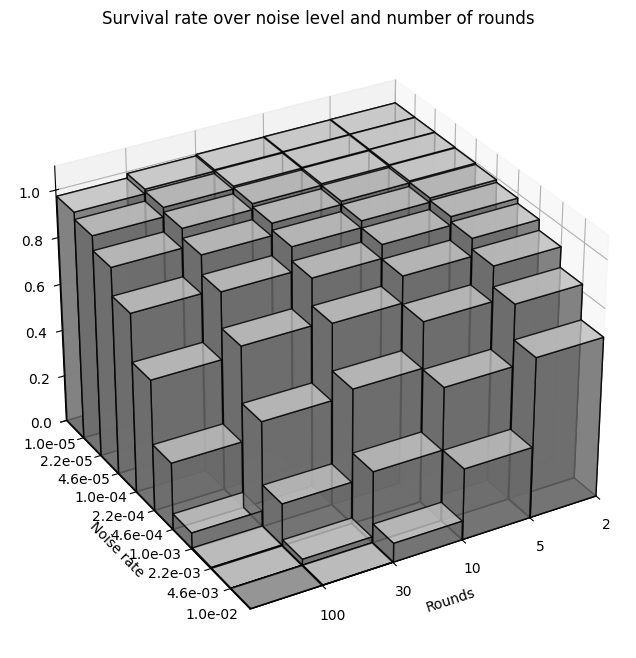

In [456]:
fig = plt.figure(figsize=(8,8))  # Increase the figure size for more whitespace
ax = fig.add_subplot(111, projection='3d')

# X, Y values for rounds/noise
xpos, ypos = np.meshgrid(np.arange(len(rounds)), np.arange(len(noises)), indexing='ij')
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = dy = 0.99 * np.ones_like(zpos)
dz = survivors.T.flatten() / 10000000  # flatten in the correct order

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color = 'white', alpha = 0.8, edgecolor = 'black')

# Set correct labels and ticks
ax.set_xlabel('Rounds')
ax.set_ylabel('Noise rate')
#ax.set_zlabel('Survivors (out of 10,000,000)')

ax.set_xticks(np.arange(len(rounds)))
ax.set_xticklabels([f"{int(r)}" for r in rounds])
ax.set_yticks(np.arange(len(noises)))
ax.set_yticklabels([f"{n:.1e}" for n in noises])

ax.set_title('Survival rate over noise level and number of rounds')

# Zoom out: Increase space around axes to avoid clipping
# autoscale z to provide some space on top for z axis ticks & labels
zmax = dz.max() if dz.size else 1
ax.set_zlim(0, zmax * 1.1)
ax.set_xlim(0, len(rounds))
ax.set_ylim(0, len(noises))

ax.view_init(30, 60)

plt.show()


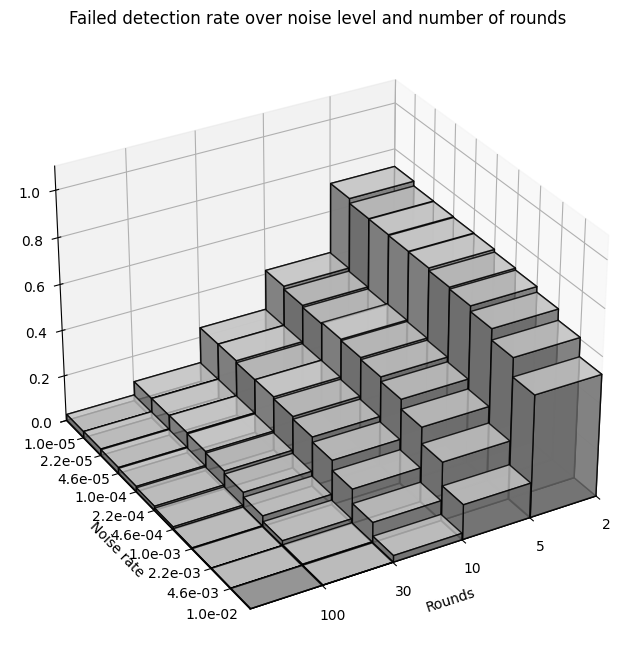

In [453]:
fig = plt.figure(figsize=(8,8))  # Increase the figure size for more whitespace
ax = fig.add_subplot(111, projection='3d')

# X, Y values for rounds/noise
xpos, ypos = np.meshgrid(np.arange(len(rounds)), np.arange(len(noises)), indexing='ij')
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = dy = 0.99 * np.ones_like(zpos)
dz = errorspostfilter.T.flatten() / errorsprefilter.T.flatten() # flatten in the correct order

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color = 'white', alpha = 0.8, edgecolor = 'black')

# Set correct labels and ticks
ax.set_xlabel('Rounds')
ax.set_ylabel('Noise rate')
#ax.set_zlabel('Survivors (out of 10,000,000)')

ax.set_xticks(np.arange(len(rounds)))
ax.set_xticklabels([f"{int(r)}" for r in rounds])
ax.set_yticks(np.arange(len(noises)))
ax.set_yticklabels([f"{n:.1e}" for n in noises])

ax.set_title('Failed detection rate over noise level and number of rounds')

# Zoom out: Increase space around axes to avoid clipping
# autoscale z to provide some space on top for z axis ticks & labels
ax.set_zlim(0, 1.1)
ax.set_xlim(0, len(rounds))
ax.set_ylim(0, len(noises))

ax.view_init(30, 60)

plt.show()


In [381]:
errorspostfilter

array([[9.40000e+02, 9.58000e+02, 1.15100e+03, 1.65400e+03, 3.46800e+03],
       [2.00300e+03, 2.26700e+03, 2.50100e+03, 3.61800e+03, 7.25700e+03],
       [4.33200e+03, 4.58100e+03, 5.32100e+03, 7.51700e+03, 1.43760e+04],
       [9.26700e+03, 1.00480e+04, 1.10820e+04, 1.57960e+04, 2.70810e+04],
       [2.00190e+04, 2.11450e+04, 2.35570e+04, 3.06100e+04, 4.21340e+04],
       [4.23760e+04, 4.44330e+04, 4.68100e+04, 5.40820e+04, 4.76230e+04],
       [8.96270e+04, 9.01170e+04, 8.90210e+04, 7.65640e+04, 2.40130e+04],
       [1.84624e+05, 1.68308e+05, 1.43291e+05, 6.63310e+04, 2.36100e+03],
       [3.58314e+05, 2.68898e+05, 1.64862e+05, 2.06240e+04, 5.00000e+00],
       [6.33503e+05, 3.10096e+05, 9.61640e+04, 7.55000e+02, 0.00000e+00]])

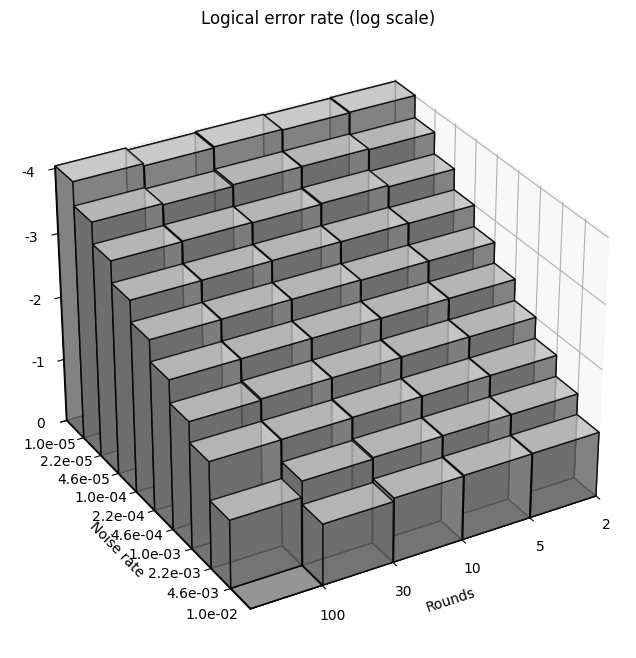

In [457]:
fig = plt.figure(figsize=(8,8))  # Increase the figure size for more whitespace
ax = fig.add_subplot(111, projection='3d')

# X, Y values for rounds/noise
xpos, ypos = np.meshgrid(np.arange(len(rounds)), np.arange(len(noises)), indexing='ij')
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = dy = 0.99 * np.ones_like(zpos)
survivorscopy = survivors.copy()
survivorscopy[survivorscopy == 0] = 1
errorspostfiltercopy = errorspostfilter.copy()
errorspostfiltercopy[errorspostfiltercopy == 0] = 1
dz = errorspostfiltercopy.T.flatten() / survivorscopy.T.flatten()
dz = -np.log10(dz)

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color = 'white', alpha = 0.8, edgecolor = 'black')

# Set correct labels and ticks
ax.set_xlabel('Rounds')
ax.set_ylabel('Noise rate')
#ax.set_zlabel('Survivors (out of 10,000,000)')

ax.set_xticks(np.arange(len(rounds)))
ax.set_xticklabels([f"{int(r)}" for r in rounds])
ax.set_yticks(np.arange(len(noises)))
ax.set_yticklabels([f"{n:.1e}" for n in noises])
ax.set_zticks(np.arange(0, np.ceil(np.max(dz)), 1))
ax.set_zticklabels([-x for x in range(int(np.ceil(np.max(dz))))])

ax.set_title('Logical error rate (log scale)')

# Zoom out: Increase space around axes to avoid clipping
# autoscale z to provide some space on top for z axis ticks & labels
ax.set_zlim(0, np.max(dz))
ax.set_xlim(0, len(rounds))
ax.set_ylim(0, len(noises))

ax.view_init(30, 60)

plt.show()


In [423]:
lers = errorspostfiltercopy / survivorscopy
pointsnogauge = []
for i in range(len(noises)):
    pointsnogauge.append(np.mean(np.log10(lers[i,:])))

In [429]:
lers2 = errorspostfiltercopy / survivorscopy
pointsnogauge2 = []
for i in range(len(noises)):
    pointsnogauge2.append(np.mean(np.log10(lers2[i,:])))

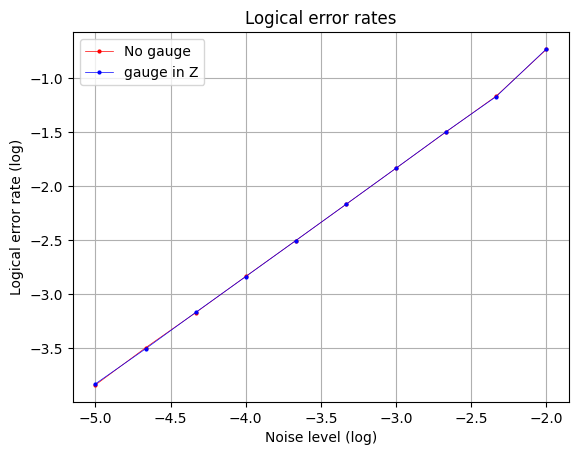

In [435]:
plt.plot(np.log10(noises), pointsnogauge, color = 'red', label = 'No gauge', marker = 'o', markersize = 2, linewidth = 0.5)
plt.plot(np.log10(noises), pointsnogauge2, color = 'blue', label = 'gauge in Z', marker = 'o', markersize = 2, linewidth = 0.5)
plt.grid()
plt.legend()
plt.xlabel('Noise level (log)')
plt.ylabel('Logical error rate (log)')
plt.title('Logical error rates')
plt.show()

In [417]:
import math
size = 10000000
p = 0.03
p23 = 0.02
p13 = 0.01
def bterm(p, n, k):
    return math.comb(n, k) * p**k * (1-p)**(n-k)

print(size * (bterm(p, 4, 0)))
print(size * 4*2*p13**2*(1-p)**2)
print(size * (4*p13*(1-p)**3))
print(size * 4*2*p13**2*(1-p)**2)
print(size * (2*p13*(1-p)**3))
print(size * (2*p13*(1-p)**3))
print(size * (2*p13*(1-p)**3))
print(size * (2*p13*(1-p)**3))

8852928.1
7527.2
365069.2
7527.2
182534.6
182534.6
182534.6
182534.6


In [327]:
circuit.diagram()

q0: -R-X_ERROR(0)-H-DEPOLARIZE1(0.1)-@-DEPOLARIZE2(0)-@-DEPOLARIZE2(0)-@-DEPOLARIZE2(0)-DEPOLARIZE1(0)----------------@-DEPOLARIZE2(0)------------------------------------------------------------------------------------------------------------------------------------------------X-------DEPOLARIZE2(0)------------------------------------------------------------------------------MR(0):rec[5]-X_ERROR(0)-OBSERVABLE_INCLUDE:L0*=rec[0]*rec[1]*rec[2]*rec[3]*rec[4]*rec[5]*rec[6]-
                                     | |              | |              | |                                            | |                                                                                                                                                             |       |
q1: -R-X_ERROR(0)--------------------X-DEPOLARIZE2(0)-|-|--------------|-|--------------DEPOLARIZE1(0)----------------|-|--------------@-DEPOLARIZE2(0)-------------------------------------------------------------------------------------------------------------------------------|-X-----|--------------DEPOLARIZE2(0)---------------------------------------------------------------MR(0):rec[6]-X_ERROR(0)-------------------------------------------------------------------------
                                                      | |              | |                                            | |              | |                                                                                                                                            | |     |              |
q2: -R-X_ERROR(0)-------------------------------------X-DEPOLARIZE2(0)-|-|--------------DEPOLARIZE1(0)----------------|-|--------------|-|--------------@-DEPOLARIZE2(0)--------------------------------------------------------------------------------------------------------------|-|-X---|--------------|--------------DEPOLARIZE2(0)------------------------------------------------------------------------------------------------------------------------------------------------
                                                                       | |                                            | |              | |              | |                                                                                                                           | | |   |              |              |
q3: -R-X_ERROR(0)------------------------------------------------------X-DEPOLARIZE2(0)-DEPOLARIZE1(0)----------------|-|--------------|-|--------------|-|--------------@-DEPOLARIZE2(0)---------------------------------------------------------------------------------------------|-|-|-X-|--------------|--------------|--------------DEPOLARIZE2(0)---------------------------------------------------------------------------------------------------------------------------------
                                                                                                                      | |              | |              | |              | |                                                                                                          | | | | |              |              |              |
q4: ---------------------------------------------------------------------R--------------X_ERROR(0)-----DEPOLARIZE1(0)-X-DEPOLARIZE2(0)-X-DEPOLARIZE2(0)-X-DEPOLARIZE2(0)-X-DEPOLARIZE2(0)-MR(0):rec[0]-X_ERROR(0)---------------------------------------------------------------------|-|-|-|-|--------------|--------------|--------------|----------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                                                                                                                                                                                                      | | | | |              |              |              |
q5: ----------------------------------------------

In [30]:
sampler = circuit.compile_sampler()
shots = np.array(sampler.sample_bit_packed(10000))
print(shots)

[[0]
 [1]
 [1]
 ...
 [0]
 [1]
 [0]]


In [31]:
np.sum(shots[:,0])

np.uint64(5086)

In [32]:
def get_logical_error(circuit, nshots=1000000, batch_size=100000):
    ds = circuit.compile_detector_sampler()
    total_errors = 0
    total_shots = 0
    model = circuit.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(model)

    shots_remaining = nshots
    while shots_remaining > 0:
        current_batch_size = int(min(batch_size, shots_remaining))
        D, L = ds.sample(current_batch_size, separate_observables=True)
        pred = matching.decode_batch(D)
        total_errors += np.sum(pred[:, 0] != L[:, 0])
        total_shots += current_batch_size
        shots_remaining -= current_batch_size

    return total_errors / total_shots